# Implementação da LeNet-5 com PyTorch

Conforme solicitado, este notebook contém apenas a declaração da arquitetura clássica LeNet-5 utilizando a biblioteca PyTorch e TorchVision.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # Camada Conv 1: 1 canal de entrada (grayscale), 6 canais de saída, kernel 5x5
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        
        # Camada Conv 2: 6 canais de entrada, 16 canais de saída, kernel 5x5
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # Camadas Fully Connected (Densas)
        # A saída da conv2 terá 16 canais de 5x5 (supondo imagem de entrada 32x32)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Conv1 -> ReLU -> MaxPool2d (kernel 2x2, stride 2)
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        
        # Conv2 -> ReLU -> MaxPool2d (kernel 2x2, stride 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        
        # Transformando (flattening) para entrar nas camadas densas
        # Achata os dados a partir da dimensão 1 (ignorando o batch_size na dimensão 0)
        x = torch.flatten(x, 1) 
        
        # Dense 1 -> ReLU
        x = F.relu(self.fc1(x))
        
        # Dense 2 -> ReLU
        x = F.relu(self.fc2(x))
        
        # Saída (Logits)
        x = self.fc3(x)
        
        return x

# Instanciando o modelo para confirmação
model = LeNet5()
print(model)

## Visualizando os Filtros Iniciais

Abaixo podemos visualizar o estado inicial dos pesos (filtros) da primeira camada convolucional (`conv1`) logo após a inicialização aleatória da rede e antes de qualquer processo de treinamento.

In [ ]:
# Instalação das bibliotecas necessárias no kernel atual (caso não existam)
%pip install matplotlib torchvision

In [ ]:
import matplotlib.pyplot as plt

# Extraindo os pesos da camada conv1
# O formato dos pesos na conv1 é [out_channels, in_channels, kernel_height, kernel_width]
# Para a LeNet-5, temos [6, 1, 5, 5]
filters = model.conv1.weight.data.clone().numpy()

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    # Selecionamos o filtro i, com o canal 0 (pois só há 1 canal de entrada)
    ax = axes[i]
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filtro {i+1}')
    ax.axis('off')

plt.suptitle('Estado inicial dos pesos da Conv1 (Antes do Treinamento)', fontsize=16)
plt.show()

## Importando e Visualizando o Dataset MNIST

A LeNet-5 foi projetada originalmente para reconhecer dígitos manuscritos. Vamos preparar o dataset MNIST e visualizar algumas de suas imagens.

In [ ]:
# Transformação para converter as imagens em tensores e normalizá-las
transform = transforms.Compose([
    transforms.Resize((32, 32)), # LeNet-5 requer imagens 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carregando o dataset de treino do MNIST
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transform, 
                                           download=True)

# Usando o DataLoader para criar lotes (batches)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=6, 
                                           shuffle=True)

# Pegando um batch de imagens e rótulos
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Configurando a figura do matplotlib
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    ax = axes[i]
    # Desnormalizando a imagem para visualização (img * std + mean)
    img = images[i][0].numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Rótulo: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Exemplos de Imagens do MNIST', fontsize=16)
plt.show()

## Treinamento do Modelo

Agora vamos definir a função de custo (Cross Entropy Loss) e o otimizador (Adam ou SGD) para iniciar o treinamento da rede neural LeNet-5 com os dados de treinamento.

In [ ]:
import torch.optim as optim

# Definimos a Função de Perda e o Otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Definir dispositivo de hardware (GPU ou CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")
model.to(device)

# Loop de Treinamento
epochs = 5
print("Iniciando o treinamento...")
for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # Obter os inputs; data é uma lista de [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)

        # Zerar as derivadas/gradientes
        optimizer.zero_grad()

        # Forward (caminho de ida) + backward (caminho de volta para calcular os gradientes) + optimize (atualizar pesos)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Imprimir estátisticas no final de vários batchs
        running_loss += loss.item()
        if i % 2000 == 1999:    # printar a cada 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Treinamento Finalizado!')

## Avaliação do Modelo no Conjunto de Teste

Após treinar o modelo, precisamos avaliar sua performance utilizando dados que ele nunca viu duranto o treinamento. Para isso, vamos carregar o conjunto de testes (Test Dataset) do MNIST e calcular a precisão (accuracy) global da nossa rede neural.

In [ ]:
# Carregando o dataset de teste do MNIST
test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transform, 
                                          download=True)

# DataLoader para os dados de teste
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=64, 
                                          shuffle=False)

correct = 0
total = 0

# Como estamos apenas avaliando, não precisamos calcular gradientes
with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        
        # Calcula as predições da rede
        outputs = model(images)
        
        # A classe predita é a que tem a maior energia
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisão (Accuracy) da rede neural nas 10000 imagens de teste: {100 * correct / total} %')

In [ ]:
# Preparar os contadores para cada classe (dígitos 0 a 9)
classes = [str(i) for i in range(10)]
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # Agrupar as predições corretas para cada classe
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label.item()]] += 1
            total_pred[classes[label.item()]] += 1

# Imprimir a precisão por classe
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Precisão para classe {classname:5s} is: {accuracy:.1f} %')

## Salvando e Carregando o Modelo

Uma vez que o modelo foi treinado e apresentou uma boa precisão, podemos salvar seus pesos em um arquivo `.pth`. Isso evita que precisemos treinar a rede do zero toda vez que quisermos utilizá-la para classificar novos dígitos numéricos.

In [ ]:
import os

PATH = './lenet5_mnist_model.pth'

# É uma boa prática salvar apenas o 'state_dict' (que contém os pesos aprendidos), em vez de todo o objeto modelo.
torch.save(model.state_dict(), PATH)

print(f"Pesos do modelo salvos com sucesso no arquivo local: {os.path.abspath(PATH)}")

# ------------- OPCIONAL: Como carregar o modelo no futuro -------------
# model_loaded = LeNet5() # Precisamos instanciar a estrutura do modelo novamente
# model_loaded.load_state_dict(torch.load(PATH))
# model_loaded.eval() # Definimos para modo de avaliação antes da inferência
# print("Modelo recarregado do disco com sucesso!")

## Carregando o Modelo e Fazendo Inferências Soltas

Nesta etapa extra, vamos instanciar estruturalmente uma nova LeNet-5, carregar nela os pesos que salvamos (`.pth`), e solicitar que esta inteligência artificial faça uma classificação de um único dígito (para provar que ela realmente aprendeu e pode ser usada em produção).

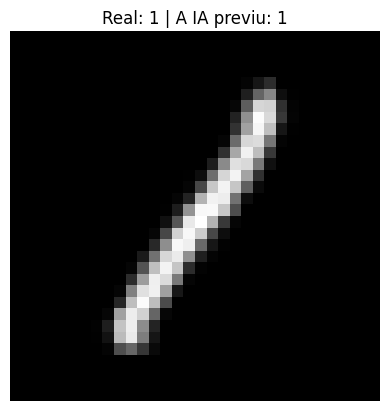

In [10]:
import random
import matplotlib.pyplot as plt

# 1. Instanciamos uma rede 'limpa' do zero
loaded_model = LeNet5()

# 2. Carregamos o 'cérebro' do disco na rede (temos q definir onde mapear baseado no hw atual)
PATH = './lenet5_mnist_model.pth'
loaded_model.load_state_dict(torch.load(PATH, map_location=device, weights_only=True))
loaded_model.to(device)

# 3. Definimos ela como modo inferência (Evaluation Mode)
# Isso desliga Dropout ou BatchNorm caso a arquitetura tivesse estes itens
loaded_model.eval()

# 4. Vamos pegar uma IMAGEM ISOLADA para ela prever
# Extraindo uma imagem aleatória do Test
idx = random.randint(0, len(test_dataset) - 1)
img, label = test_dataset[idx]

# O PyTorch espera um Batch (Lote). Então fazemos img.unsqueeze(0)
# para transformar formato [1, 32, 32] em [1, 1, 32, 32] (Lote de tamanho 1)
img_batch = img.unsqueeze(0).to(device)

with torch.no_grad():
    output = loaded_model(img_batch)
    
    # Pega o valor máximo (probabilidade da classe)
    _, predicted = torch.max(output, 1)

# Desnormalizando para plotar com matplotlib
plt_img = img[0].numpy() * 0.5 + 0.5
plt.imshow(plt_img, cmap='gray')
plt.title(f"Real: {label} | A IA previu: {predicted.item()}")
plt.axis('off')
plt.show()

## Visualizando os Mapas de Características (Feature Maps)

Uma das grandes vantagens das Redes Neurais Convolucionais é que podemos "espiar" o que a rede está vendo internamente. Abaixo, pegamos a imagem anterior e a passamos apenas pela primeira camada convolucional (`conv1`), extraindo os 6 tensores resultantes e exibindo-os. Estes são os filtros de borda e padrões ativados!

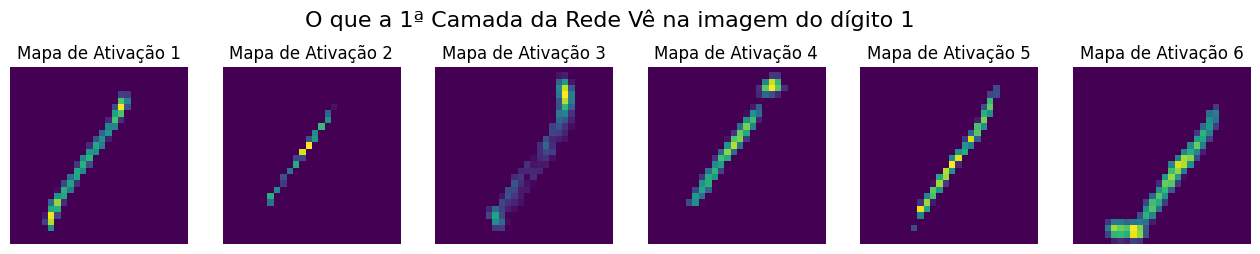

In [11]:
import torch.nn.functional as F

# Vamos pegar a imagem (img_batch) que instanciamos no bloco anterior
with torch.no_grad():
    # Em vez de chamar o forward() completo, vamos passar o dado apenas pela conv1 e relu
    conv1_out = F.relu(loaded_model.conv1(img_batch))

# O Output da conv1 tem formato [Lote, 6_canais, 28_altura, 28_largura]
feature_maps = conv1_out[0].cpu().numpy()

# Configurando o Plot (1 linha, 6 colunas para os 6 filtros da LeNet-5 conv1)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))

for i in range(6):
    ax = axes[i]
    # Mostrando cada um dos 6 canais
    ax.imshow(feature_maps[i], cmap='viridis') # Viridis é ótimo para ver intensidade de ativação
    ax.set_title(f'Mapa de Ativação {i+1}')
    ax.axis('off')

plt.suptitle(f'O que a 1ª Camada da Rede Vê na imagem do dígito {label}', fontsize=16)
plt.show()